In [27]:
#Basic Setup
import matplotlib.pyplot as plt
import numpy as np
import uproot
import pandas as pd
import matplotlib.ticker as mticker
import math
#open root file


#df = uproot.open(
 #   "/volatile/clas12/cooperb/SULI/pid_training_test.root:PhysicsEvents"
#).arrays(library="pd")
#cols = ["pid", "mc_matching_pid", "p", "theta", "beta", "chi2pid", "rich_RQ", "vz", "sector", "phi"]
#cols = ["mc_matching_pid","ftof_energy_1A", "ftof_energy_1B", "ftof_time_1A", "ftof_time_1B", "ftof_path_1A", "ftof_path_1B", "ecin_energy", "ecout_energy", "ecin_time", "ecout_time", "ecin_path", "ecout_path", "nphe_htcc"]
cols =["mc_matching_pid","pcal_energy","pcal_time","pcal_path", "ftof_energy_2", "ftof_time_2", "ftof_path_2"]
df = uproot.open("/volatile/clas12/cooperb/SULI/pid_training_v1.root:PhysicsEvents").arrays(cols, library="pd")
#creates a list of matching events (excludes events that failed matching)
matched = df[df["mc_matching_pid"] != -9999].copy()
#baseline = matched[(matched["p"]>=1)&(matched["p"]<=5)&(matched["mc_matching_pid"]==321)&passes_kplus_chi2pid_cut(matched["chi2pid"], matched["p"])]
#baseline = matched[(matched["p"]>=1)&(matched["p"]<=5)&(abs(matched["chi2pid"])<1)]
direct = "/work/clas12/CooperBe/Argonne2026/suli2026_pid/figures/audit/"  #path directory for saving pngs :)
#matched=baseline

matched = matched[(matched["ftof_time_2"]!=-9999)&(matched["ftof_time_2"]!=0)]
print("ftof_path_1A:  ", matched["ftof_time_2"].describe())
print("\nQuick eyeball:")
print(f"  ftof_time_1A range: [{matched['ftof_time_2'].min():.2f}, {matched['ftof_time_2'].max():.2f}]")


ftof_path_1A:   count    344418.000000
mean        149.506557
std           7.045622
min         109.450363
25%         147.165668
50%         147.854126
75%         148.890812
max        2815.528076
Name: ftof_time_2, dtype: float64

Quick eyeball:
  ftof_time_1A range: [109.45, 2815.53]


In [ ]:
fig, ax2 = plt.subplots(figsize=(7, 5)) #plots just the True pid as a histogram
ax2.hist(matched["sector"].clip(0, 6), bins=10, histtype="step", density=True)
ax2.set_xlabel("sector"); ax2.set_ylabel("Density");
ax2.set_xticks(np.linspace(0, 6, 10))
fig.tight_layout()
fig.savefig(direct+"sector.png", dpi=150)
plt.show()

In [ ]:
fig, ax2 = plt.subplots(figsize=(7, 5)) #plots just the True pid as a histogram
ax2.hist(matched["p"].clip(0.5, 5), bins=100, histtype="step", density=True)
ax2.set_xlabel("Momentum"); ax2.set_ylabel("Density");
ax2.set_xticks(np.linspace(0, 5, 10))
fig.tight_layout()
fig.savefig(direct+"momentum.png", dpi=150)
plt.show()

In [ ]:
fig, ax2 = plt.subplots(figsize=(7, 5)) #plots just the True pid as a histogram
ax2.hist(matched["vz"].clip(0, 1.4), bins=100, histtype="step", density=True)
ax2.set_xlabel("Vz"); ax2.set_ylabel("Density");
ax2.set_xticks(np.linspace(0, 1.4, 10))
fig.tight_layout()
fig.savefig(direct+"vz.png", dpi=150)
plt.show()

In [ ]:
fig, ax2 = plt.subplots(figsize=(7, 5)) #plots just the True pid as a histogram
ax2.hist(matched["theta"].clip(0, 360), bins=100, histtype="step", density=True)
ax2.set_xlabel("Theta"); ax2.set_ylabel("Density");
ax2.set_xticks(np.linspace(0, 360, 10))
fig.tight_layout()
fig.savefig(direct+"theta.png", dpi=150)
plt.show()

In [ ]:
fig, ax2 = plt.subplots(figsize=(7, 5)) #plots just the True pid as a histogram
ax2.hist(matched["phi"].clip(0, 360), bins=100, histtype="step", density=True)
ax2.set_xlabel("Phi"); ax2.set_ylabel("Density");
ax2.set_xticks(np.linspace(0, 360, 10))
fig.tight_layout()
fig.savefig(direct+"phi.png", dpi=150)
plt.show()

In [ ]:
fig, ax2 = plt.subplots(figsize=(7, 5)) #plots just the True pid as a histogram
ax2.hist(matched["beta"].clip(0, 1), bins=100, histtype="step", density=True)
ax2.set_xlabel("Beta"); ax2.set_ylabel("Density");
ax2.set_xticks(np.linspace(0, 1, 10))
fig.tight_layout()
fig.savefig(direct+"beta.png", dpi=150)
plt.show()

In [ ]:
fig, ax2 = plt.subplots(figsize=(7, 5)) #plots just the True pid as a histogram
ax2.hist(matched["chi2pid"].clip(-10, 10), bins=100, histtype="step", density=True)
ax2.set_xlabel("Chi2Pid"); ax2.set_ylabel("Density");
ax2.set_xticks(np.linspace(-10, 10, 10))
fig.tight_layout()
fig.savefig(direct+"chi2pid.png", dpi=150)
plt.show()

In [ ]:
#cut=matched[(matched["ftof_time_1A"]!=-9999) & (matched["ftof_time_1A"]!=0)]
print(matched["ftof_time_1A"].value_counts().head(15))

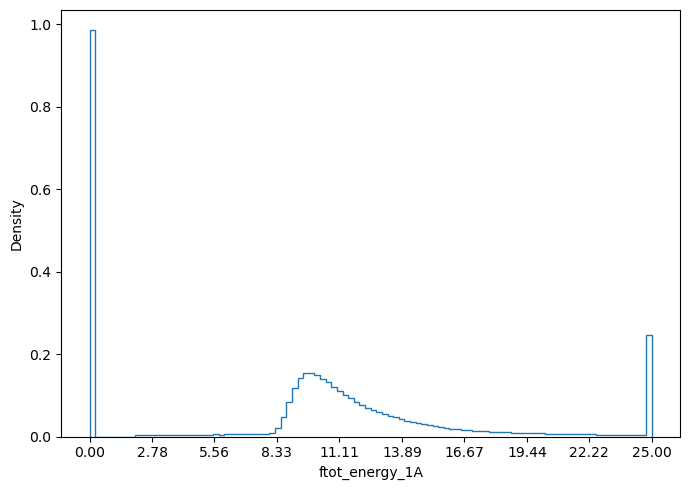

In [28]:
fig, ax2 = plt.subplots(figsize=(7, 5)) #plots just the True pid as a histogram
ax2.hist(matched["ftof_energy_1A"].clip(0, 25), bins=100, histtype="step", density=True)
ax2.set_xlabel("ftot_energy_1A"); ax2.set_ylabel("Density");
ax2.set_xticks(np.linspace(0, 25, 10))
fig.tight_layout()
fig.savefig(direct+"ftot_energy_1A.png", dpi=150)
plt.show()

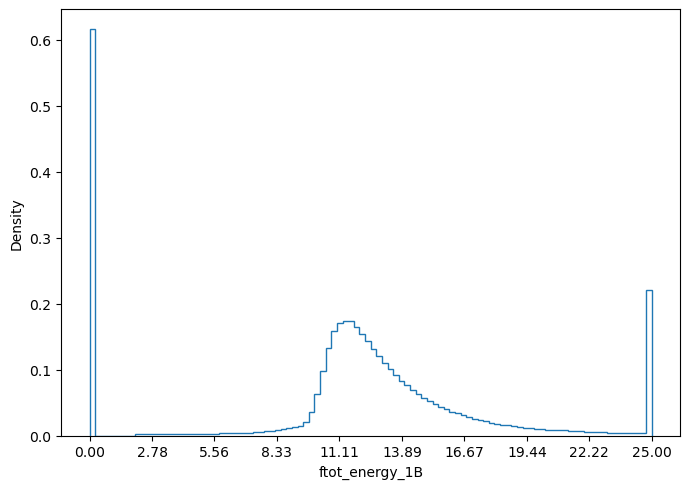

In [27]:
fig, ax2 = plt.subplots(figsize=(7, 5)) #plots just the True pid as a histogram
ax2.hist(matched["ftof_energy_1B"].clip(0, 25), bins=100, histtype="step", density=True)
ax2.set_xlabel("ftot_energy_1B"); ax2.set_ylabel("Density");
ax2.set_xticks(np.linspace(0,25, 10))
fig.tight_layout()
fig.savefig(direct+"ftot_energy_1B.png", dpi=150)
plt.show()

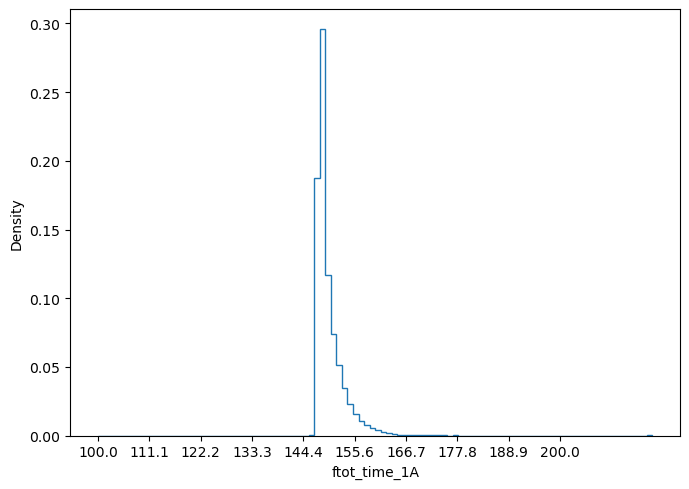

In [13]:
fig, ax2 = plt.subplots(figsize=(7, 5)) #plots just the True pid as a histogram
ax2.hist(matched["ftof_time_1A"].clip(100, 220), bins=100, histtype="step", density=True)
ax2.set_xlabel("ftot_time_1A"); ax2.set_ylabel("Density");
ax2.set_xticks(np.linspace(100, 200, 10))
fig.tight_layout()
fig.savefig(direct+"ftot_time_1A.png", dpi=150)
plt.show()


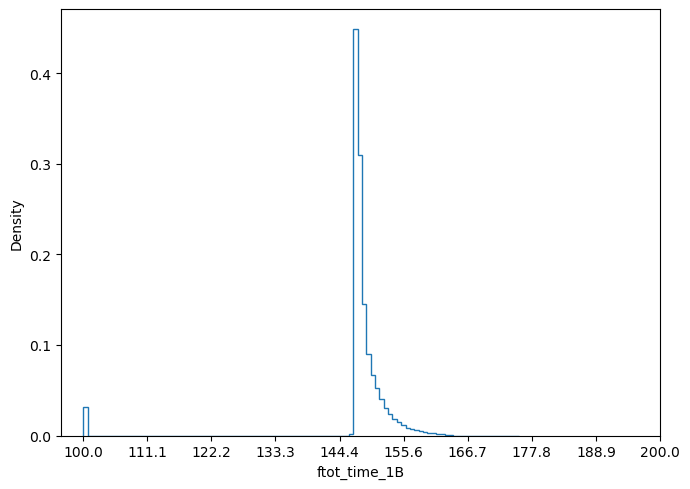

In [14]:
fig, ax2 = plt.subplots(figsize=(7, 5)) #plots just the True pid as a histogram
ax2.hist(matched["ftof_time_1B"].clip(100, 200), bins=100, histtype="step", density=True)
ax2.set_xlabel("ftot_time_1B"); ax2.set_ylabel("Density");
ax2.set_xticks(np.linspace(100, 200, 10))
fig.tight_layout()
fig.savefig(direct+"ftot_time_1B.png", dpi=150)
plt.show()


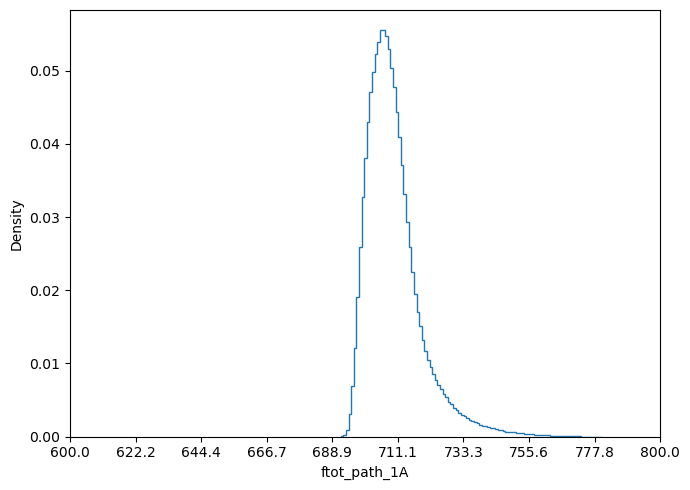

In [2]:
fig, ax2 = plt.subplots(figsize=(7, 5)) #plots just the True pid as a histogram
ax2.hist(matched["ftof_path_1A"].clip(600, 800), bins=100, histtype="step", density=True)
ax2.set_xlabel("ftot_path_1A"); ax2.set_ylabel("Density");
ax2.set_xticks(np.linspace(600, 800, 10))
fig.tight_layout()
fig.savefig(direct+"ftot_path_1A.png", dpi=150)
plt.show()


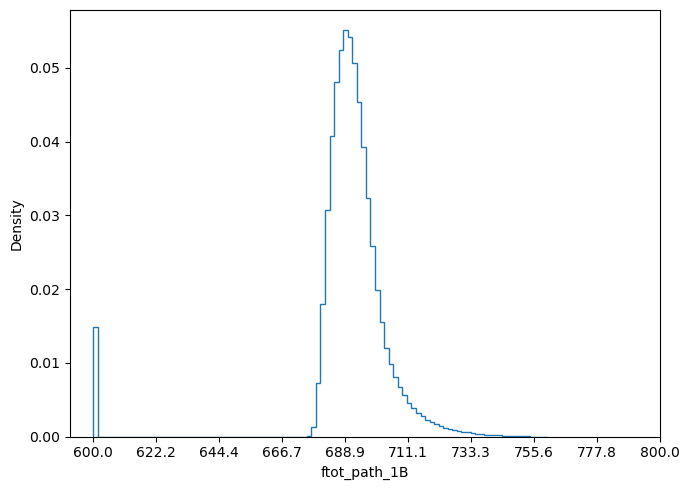

In [3]:
fig, ax2 = plt.subplots(figsize=(7, 5)) #plots just the True pid as a histogram
ax2.hist(matched["ftof_path_1B"].clip(600, 800), bins=100, histtype="step", density=True)
ax2.set_xlabel("ftot_path_1B"); ax2.set_ylabel("Density");
ax2.set_xticks(np.linspace(600, 800, 10))
fig.tight_layout()
fig.savefig(direct+"ftot_path_1B.png", dpi=150)
plt.show()


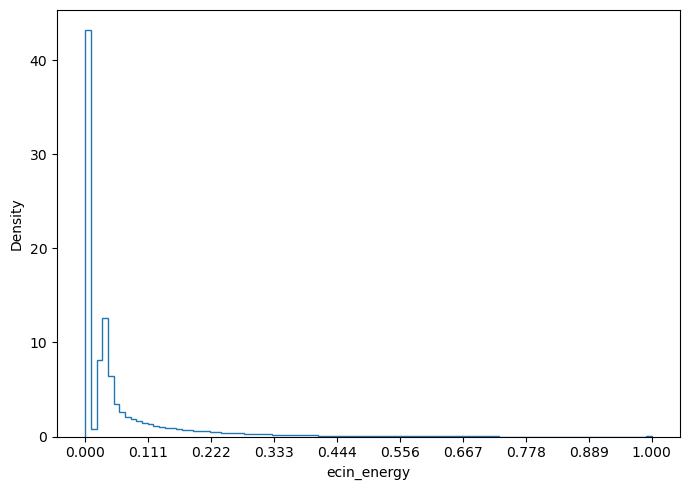

In [15]:
fig, ax2 = plt.subplots(figsize=(7, 5)) #plots just the True pid as a histogram
ax2.hist(matched["ecin_energy"].clip(0, 1), bins=100, histtype="step", density=True)
ax2.set_xlabel("ecin_energy"); ax2.set_ylabel("Density");
ax2.set_xticks(np.linspace(0, 1, 10))
fig.tight_layout()
fig.savefig(direct+"ecin_energy.png", dpi=150)
plt.show()

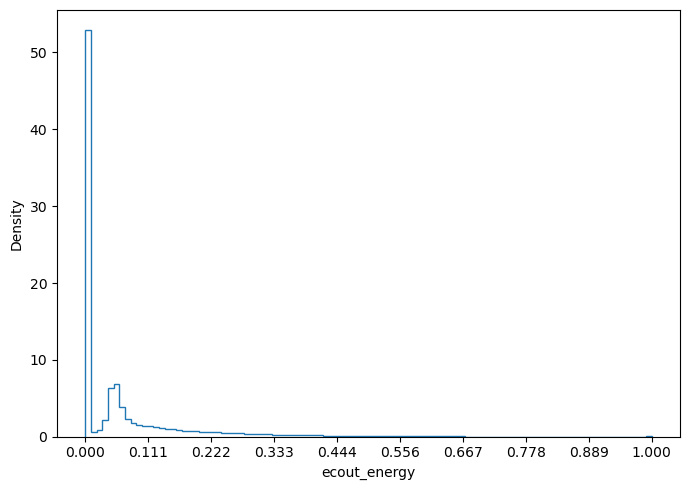

In [16]:
fig, ax2 = plt.subplots(figsize=(7, 5)) #plots just the True pid as a histogram
ax2.hist(matched["ecout_energy"].clip(0, 1), bins=100, histtype="step", density=True)
ax2.set_xlabel("ecout_energy"); ax2.set_ylabel("Density");
ax2.set_xticks(np.linspace(0, 1, 10))
fig.tight_layout()
fig.savefig(direct+"ecout_energy.png", dpi=150)
plt.show()

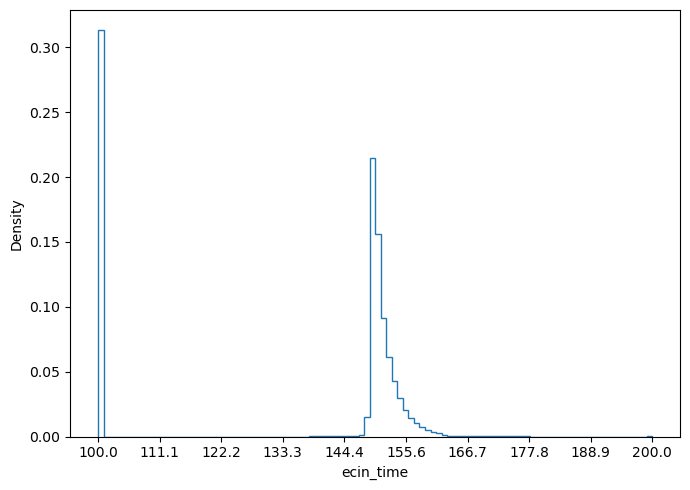

In [4]:
fig, ax2 = plt.subplots(figsize=(7, 5)) #plots just the True pid as a histogram
ax2.hist(matched["ecin_time"].clip(100, 200), bins=100, histtype="step", density=True)
ax2.set_xlabel("ecin_time"); ax2.set_ylabel("Density");
ax2.set_xticks(np.linspace(100, 200, 10))
fig.tight_layout()
fig.savefig(direct+"ecin_time.png", dpi=150)
plt.show()

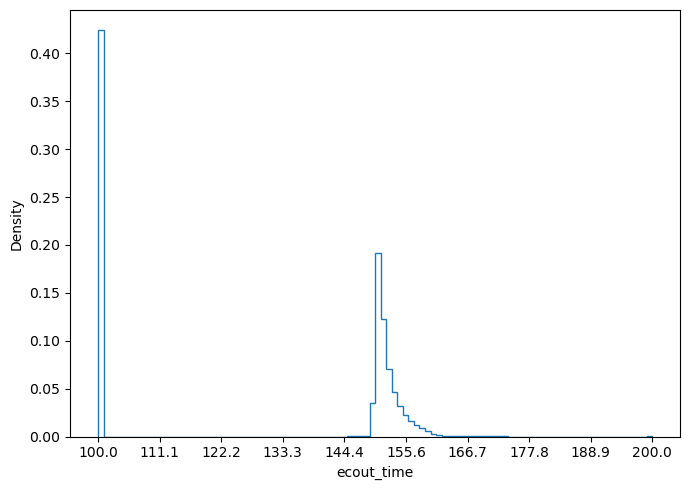

In [5]:
fig, ax2 = plt.subplots(figsize=(7, 5)) #plots just the True pid as a histogram
ax2.hist(matched["ecout_time"].clip(100,200), bins=100, histtype="step", density=True)
ax2.set_xlabel("ecout_time"); ax2.set_ylabel("Density");
ax2.set_xticks(np.linspace(100, 200, 10))
fig.tight_layout()
fig.savefig(direct+"ecout_time.png", dpi=150)
plt.show()

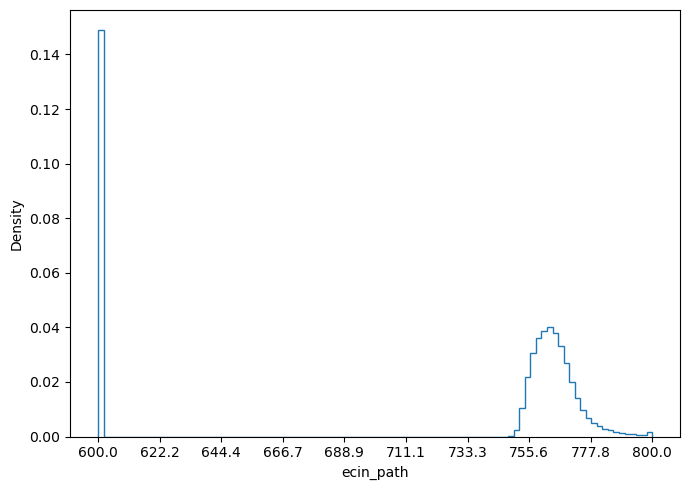

In [7]:
fig, ax2 = plt.subplots(figsize=(7, 5)) #plots just the True pid as a histogram
ax2.hist(matched["ecin_path"].clip(600, 800), bins=100, histtype="step", density=True)
ax2.set_xlabel("ecin_path"); ax2.set_ylabel("Density");
ax2.set_xticks(np.linspace(600, 800, 10))
fig.tight_layout()
fig.savefig(direct+"ecin_path.png", dpi=150)
plt.show()

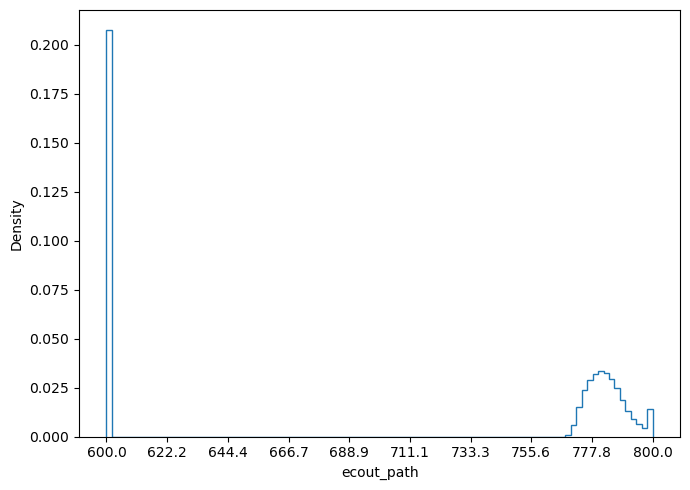

In [8]:
fig, ax2 = plt.subplots(figsize=(7, 5)) #plots just the True pid as a histogram
ax2.hist(matched["ecout_path"].clip(600, 800), bins=100, histtype="step", density=True)
ax2.set_xlabel("ecout_path"); ax2.set_ylabel("Density");
ax2.set_xticks(np.linspace(600, 800, 10))
fig.tight_layout()
fig.savefig(direct+"ecout_path.png", dpi=150)
plt.show()

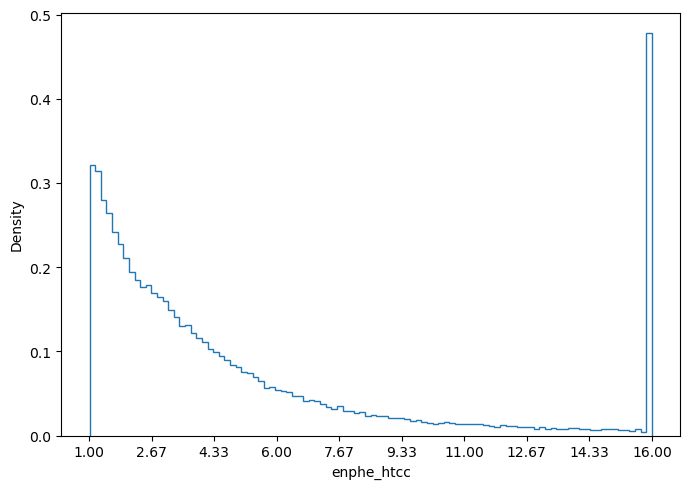

In [11]:
fig, ax2 = plt.subplots(figsize=(7, 5)) #plots just the True pid as a histogram
ax2.hist(matched["nphe_htcc"].clip(1, 16), bins=100, histtype="step", density=True)
ax2.set_xlabel("enphe_htcc"); ax2.set_ylabel("Density");
ax2.set_xticks(np.linspace(1, 16, 10))
fig.tight_layout()
fig.savefig(direct+"nphe_htcc.png", dpi=150)
plt.show()

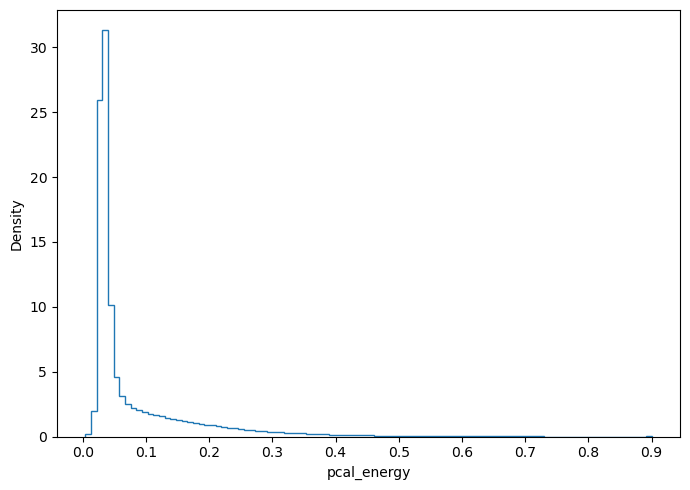

In [12]:
fig, ax2 = plt.subplots(figsize=(7, 5)) #plots just the True pid as a histogram
ax2.hist(matched["pcal_energy"].clip(0,0.9), bins=100, histtype="step", density=True)
ax2.set_xlabel("pcal_energy"); ax2.set_ylabel("Density");
ax2.set_xticks(np.linspace(0, 0.9, 10))
fig.tight_layout()
fig.savefig(direct+"pcal_energy.png", dpi=150)
plt.show()

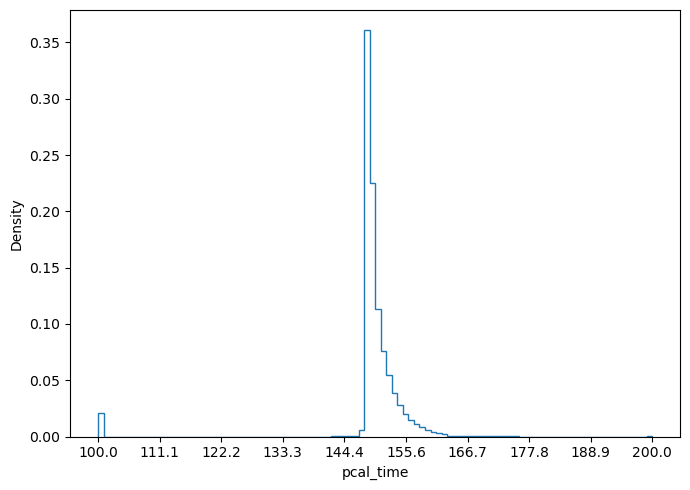

In [17]:
fig, ax2 = plt.subplots(figsize=(7, 5)) #plots just the True pid as a histogram
ax2.hist(matched["pcal_time"].clip(100,200), bins=100, histtype="step", density=True)
ax2.set_xlabel("pcal_time"); ax2.set_ylabel("Density");
ax2.set_xticks(np.linspace(100, 200, 10))
fig.tight_layout()
fig.savefig(direct+"pcal_time.png", dpi=150)
plt.show()

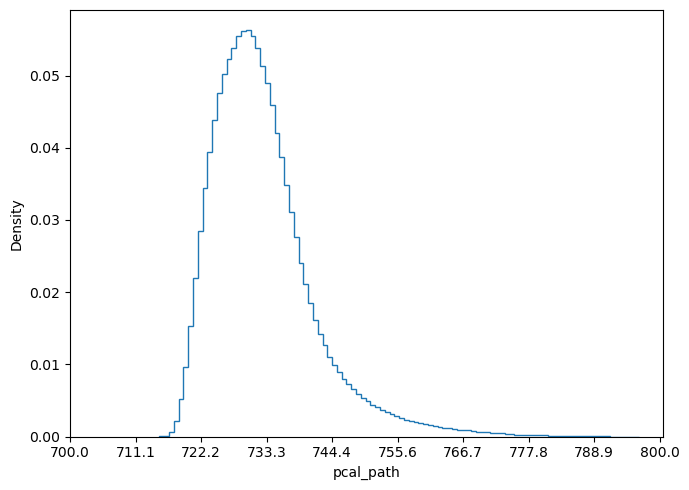

In [19]:
fig, ax2 = plt.subplots(figsize=(7, 5)) #plots just the True pid as a histogram
ax2.hist(matched["pcal_path"].clip(700,800), bins=100, histtype="step", density=True)
ax2.set_xlabel("pcal_path"); ax2.set_ylabel("Density");
ax2.set_xticks(np.linspace(700, 800, 10))
fig.tight_layout()
fig.savefig(direct+"pcal_path.png", dpi=150)
plt.show()

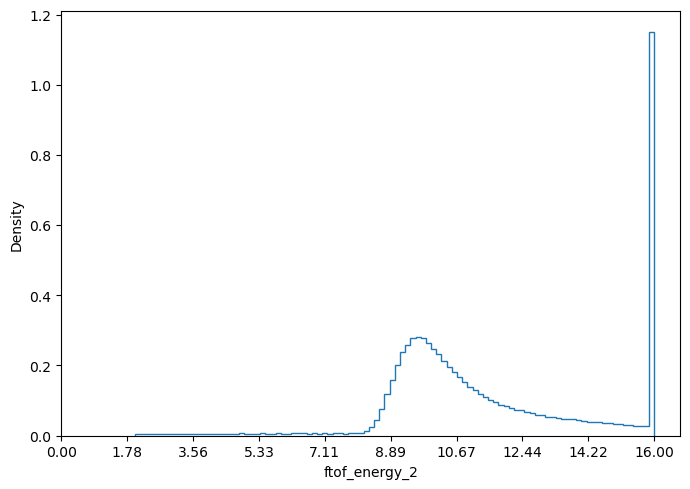

In [26]:
fig, ax2 = plt.subplots(figsize=(7, 5)) #plots just the True pid as a histogram
ax2.hist(matched["ftof_energy_2"].clip(0,16), bins=100, histtype="step", density=True)
ax2.set_xlabel("ftof_energy_2"); ax2.set_ylabel("Density");
ax2.set_xticks(np.linspace(0, 16, 10))
fig.tight_layout()
fig.savefig(direct+"ftof_energy_2.png", dpi=150)
plt.show()

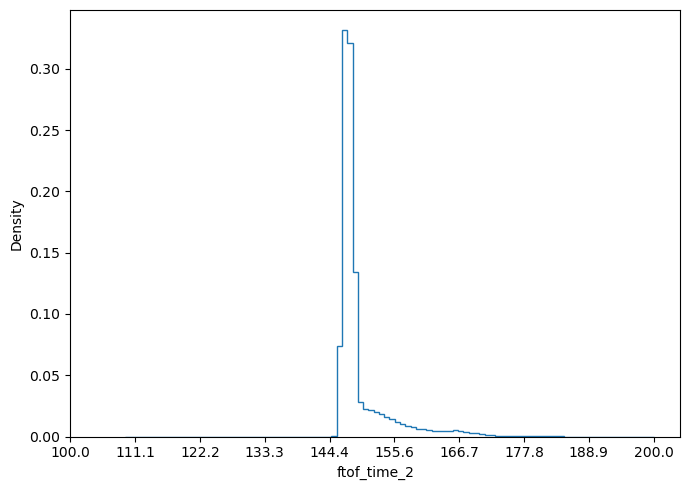

In [28]:
fig, ax2 = plt.subplots(figsize=(7, 5)) #plots just the True pid as a histogram
ax2.hist(matched["ftof_time_2"].clip(100,200), bins=100, histtype="step", density=True)
ax2.set_xlabel("ftof_time_2"); ax2.set_ylabel("Density");
ax2.set_xticks(np.linspace(100, 200, 10))
fig.tight_layout()
fig.savefig(direct+"ftof_time_2.png", dpi=150)
plt.show()

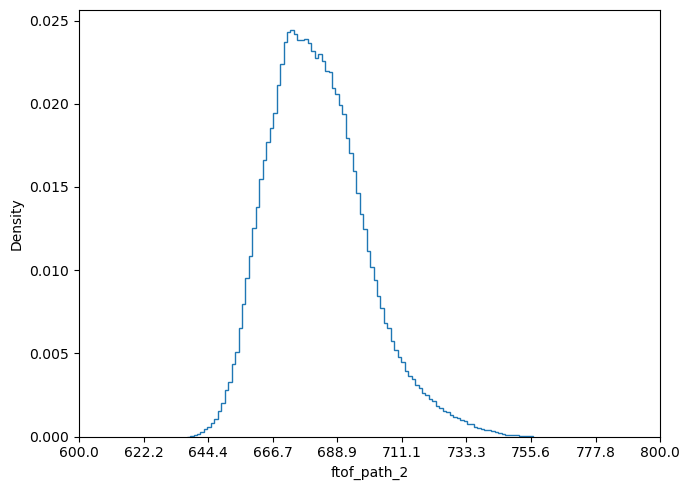

In [29]:
fig, ax2 = plt.subplots(figsize=(7, 5)) #plots just the True pid as a histogram
ax2.hist(matched["ftof_path_2"].clip(600,800), bins=100, histtype="step", density=True)
ax2.set_xlabel("ftof_path_2"); ax2.set_ylabel("Density");
ax2.set_xticks(np.linspace(600, 800, 10))
fig.tight_layout()
fig.savefig(direct+"ftof_path_2.png", dpi=150)
plt.show()